# HYPOTHESIS TESTING
# Effect of Events/Holidays on Retail Demand

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

__Datasets loading__

In [9]:
df = pd.read_csv("../../data/interim/daily_total_sales.csv")
data = df.copy()
data = data.drop(columns=["Unnamed: 0","rolling_7","rolling_28"])
# Convert date
data["date"] = pd.to_datetime(data["date"])

print(data.shape)
print(data.columns.tolist())

display(data.head())


(1913, 11)
['d', 'sales', 'date', 'weekday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'is_event']


,d,sales,date,weekday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,is_event
0,d_1,32631,2011-01-29,Saturday,1,2011,No_Event,No_Event,No_Event,No_Event,0
1,d_2,31749,2011-01-30,Sunday,1,2011,No_Event,No_Event,No_Event,No_Event,0
2,d_3,23783,2011-01-31,Monday,1,2011,No_Event,No_Event,No_Event,No_Event,0
3,d_4,25412,2011-02-01,Tuesday,2,2011,No_Event,No_Event,No_Event,No_Event,0
4,d_5,19146,2011-02-02,Wednesday,2,2011,No_Event,No_Event,No_Event,No_Event,0


__Dataset Validtion__

In [12]:
print("Missing event flags:", data["is_event"].isna().sum())

print("\nEvent-day counts:")
print(data["is_event"].value_counts())

Missing event flags: 0

Event-day counts:
is_event
0    1759
1     154
Name: count, dtype: int64


__Separate event and non-event demand__

In [13]:
event_demand = df.loc[
    data["is_event"] == 1,
    "sales"
].dropna()

non_event_demand = df.loc[
    data["is_event"] == 0,
    "sales"
].dropna()

print("Number of event days:", len(event_demand))
print("Number of non-event days:", len(non_event_demand))

Number of event days: 154
Number of non-event days: 1759


__Stats of event and non-event days:__

In [15]:
comparison = pd.DataFrame({
    "Event Days": [
        event_demand.count(),
        event_demand.mean(),
        event_demand.median(),
        event_demand.std()
    ],
    "Non-Event Days": [
        non_event_demand.count(),
        non_event_demand.mean(),
        non_event_demand.median(),
        non_event_demand.std()
    ]
}, index=[
    "Number of Days",
    "Mean Demand",
    "Median Demand",
    "Std Dev"
])

display(comparison)

,Event Days,Non-Event Days
Number of Days,154.000000,1759.000000
Mean Demand,32655.149351,34489.207504
Median Demand,33779.500000,33714.000000
Std Dev,9300.905832,7133.701801


__Visuals__

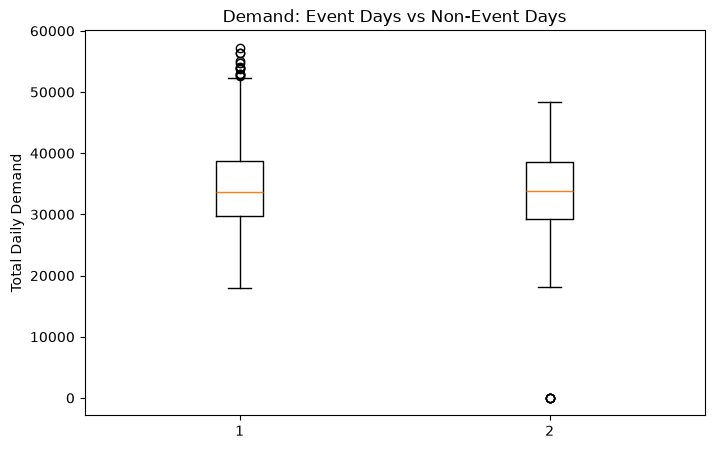

In [17]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [non_event_demand, event_demand],
    label=["Non-Event", "Event"]
)

plt.title("Demand: Event Days vs Non-Event Days")
plt.ylabel("Total Daily Demand")

plt.show()

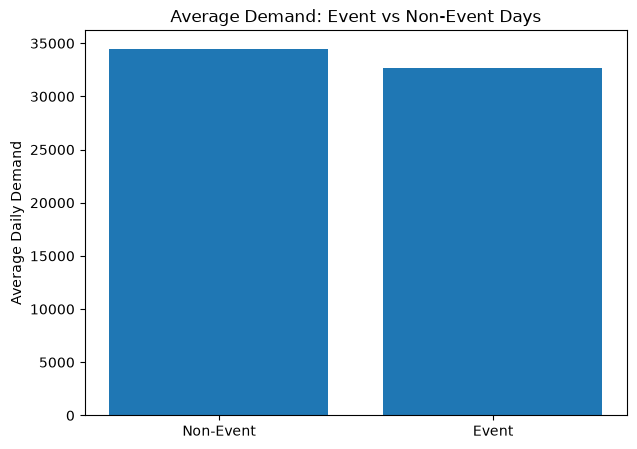

Non-event mean: 34489.20750426379
Event mean: 32655.14935064935


In [18]:
means = [
    non_event_demand.mean(),
    event_demand.mean()
]

plt.figure(figsize=(7, 5))

plt.bar(
    ["Non-Event", "Event"],
    means
)

plt.title("Average Demand: Event vs Non-Event Days")
plt.ylabel("Average Daily Demand")

plt.show()

print("Non-event mean:", non_event_demand.mean())
print("Event mean:", event_demand.mean())

Event days have slightly lower average demand.
Non-event days show more extreme high-demand values.
There is an unusual zero-demand event-day observation.



In [19]:
non_event_mean = non_event_demand.mean()
event_mean = event_demand.mean()

percentage_difference = (
    (event_mean - non_event_mean)
    / non_event_mean
) * 100

print(
    f"Event-day demand differs from non-event demand by "
    f"{percentage_difference:.2f}%"
)

Event-day demand differs from non-event demand by -5.32%


__Performing hypothesis testing using  Welch's independent two-sample t-test__

In [20]:
t_statistic, p_value = ttest_ind(
    event_demand,
    non_event_demand,
    equal_var=False
)

print("T-statistic:", t_statistic)
print("P-value:", p_value)

T-statistic: -2.386398206087781
P-value: 0.01811879291520572


In [21]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print(
        "There is statistically significant evidence that "
        "event days have different demand from non-event days."
    )
else:
    print("Fail to reject the null hypothesis.")
    print(
        "There is insufficient statistical evidence to conclude "
        "that event days have different demand from non-event days."
    )

Reject the null hypothesis.
There is statistically significant evidence that event days have different demand from non-event days.


__Event days have approximately 5.32% lower average demand than non-event days. The difference is statistically significant (p = 0.0181 < 0.05), indicating that demand differs significantly between event and non-event days__